In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
from pathlib import Path 
main_path = Path("/kaggle/input/datasets/redzapdos123/indian-driving-dataset-detections-yolov11/IDDDetectionsYOLODataset")

In [18]:
os.listdir(main_path)

['license.md', 'ReadMe.md', 'data.yaml', 'val', 'test', 'train']

In [16]:
import path 
import os
images = os.path.join(main_path,"train","images")
images = os.listdir(images)
i = 0
for image in images:
    print(image)
    i += 1
    if i > 10 :
        break 

BLR-2018-05-17_15-56-30_sideLeft_000762_r.jpg
BLR-2018-05-29_11-08-34_sideLeft_000213_r.jpg
BLR-2018-05-29_10-59-01_sideRight_000780_r.jpg
BLR-2018-06-20-07-01-47_part_14_0000431.jpg
BLR-2018-05-17_16-32-30_frontNear_0000600.jpg
BLR-2018-05-17_15-12-45_sideRight_000024_r.jpg
BLR-2018-05-29_11-55-34_rearNear_000159_r.jpg
BLR-2018-05-22_13-21-45_sideRight_0004065.jpg
BLR-2018-05-31_11-10-16_sideLeft_000019_r.jpg
BLR-2018-03-22_17-39-26_3_sideLeft_000090_r.jpg
BLR-2018-05-08_10-22-55_rearNear_000102_r.jpg


In [24]:
val_images = os.path.join(main_path, "test/images")
val_labels = os.path.join(main_path, "test/labels")
#image and labels names without extension
image_files = {
    os.path.splitext(file)[0]
    for file in os.listdir(val_images)
}
label_files = {
    os.path.splitext(file)[0]
    for file in os.listdir(val_labels)
}

matched = image_files & label_files

missing_labels = image_files - label_files
missing_images = label_files - image_files

print(f"Total Images: {len(image_files)}")
print(f"Total Labels: {len(label_files)}")
print(f"Matched Files: {len(matched)}")

print("\nImages without labels:")
for file in list(missing_labels)[:10]:
    print(file)

print("\nLabels without images:")
for file in list(missing_images)[:10]:
    print(file)


Total Images: 4197
Total Labels: 4197
Matched Files: 4197

Images without labels:

Labels without images:


In [19]:
data_yaml = f"""
path: {main_path}

train: train/images
val: val/images
test: test/images

nc: 15

names:
  0: animal
  1: autorickshaw
  2: bicycle
  3: bus
  4: car
  5: caravan
  6: motorcycle
  7: person
  8: rider
  9: traffic light
  10: traffic sign
  11: trailer
  12: train
  13: truck
  14: vehicle fallback
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


In [31]:
!nvidia-smi

Mon May 18 08:54:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00a 0:00:01


In [32]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device="cuda",
    workers=2,
    cache=False,
    amp=True,
    val=True,
    plots=True,
    pretrained=True,
    optimizer="AdamW",
    patience=5,
    save=True,
    save_period=5,
    project="vehicle_detection",
    name="yolov8n_run",
    exist_ok=True,
    verbose=True,
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, pe


image 1/1 /kaggle/input/datasets/mehrajalomtapadar/sqfsdff/aaaaa.webp: 416x640 3 autorickshaws, 3 bicycles, 9 motorcycles, 4 persons, 9 riders, 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /kaggle/working/my_inference_results/final_test_run-4
✅ Inference complete.
Results saved to: /kaggle/working/my_inference_results/final_test_run


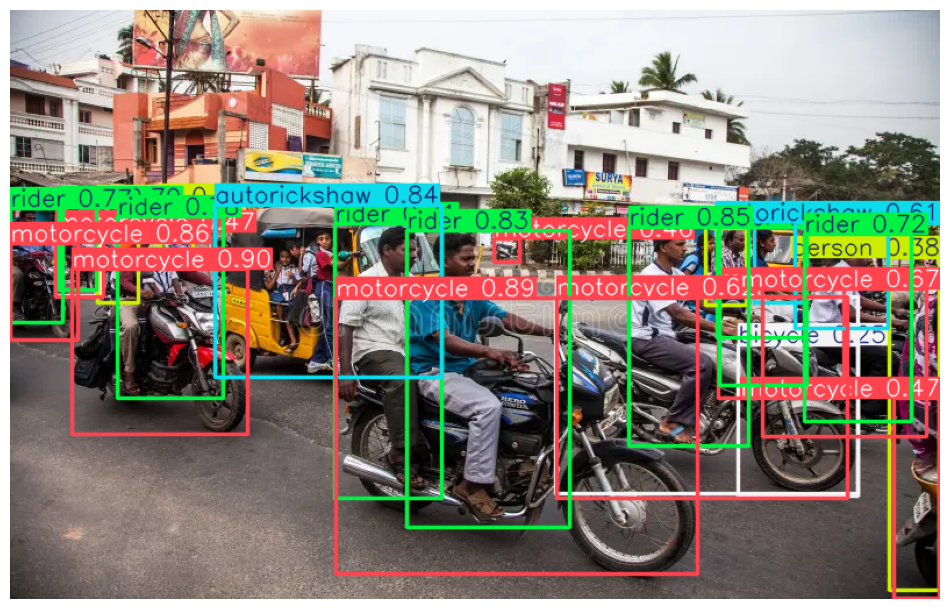

In [ ]:

model_path = '/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.pt'
model = YOLO(model_path)

test_images_path = '/kaggle/input/datasets/mehrajalomtapadar/sqfsdff/aaaaa.webp'

output_project_folder = '/kaggle/working/my_inference_results' 
output_run_name = 'final_test_run'              

results = model.predict(
    source=test_images_path,
    conf=0.25,
    save=True,
    project=output_project_folder, 
    name=output_run_name          
)

full_output_path = os.path.join(output_project_folder, output_run_name)

print(f"✅ Inference complete.")
print(f"Results saved to: {full_output_path}")

import cv2
import matplotlib.pyplot as plt
result_img = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(result_img_rgb)
plt.axis("off")
plt.show()

In [36]:
import shutil

folder_path = "/kaggle/working/runs/detect/vehicle_detection/yolov8n_run"
output_zip = "/kaggle/working/yolov8n_run.zip"

shutil.make_archive(output_zip.replace('.zip', ''), 'zip', folder_path)

print("ZIP file created:", output_zip)

ZIP file created: /kaggle/working/yolov8n_run.zip


In [37]:
#eXPORT TO ONNX FOR eDGE INFERENCE
model = YOLO("/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.pt")
model.export(
    format="onnx",
    dynamic=True,
    simplify=True,
    opset=12
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 275ms
Prepared 2 packages in 2.80s
Installed 2 packages in 13ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.93...


'/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx'

In [39]:
import onnx
onnx_model = onnx.load("/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx")
onnx.checker.check_model(onnx_model)
print("Onnx model is valid")

Onnx model is valid


Loading /kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider

image 1/1 /kaggle/input/datasets/mehrajalomtapadar/sqfsdff/aaaaa.webp: 416x640 3 autorickshaws, 3 bicycles, 9 motorcycles, 4 persons, 9 riders, 70.6ms
Speed: 2.4ms preprocess, 70.6ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 640)


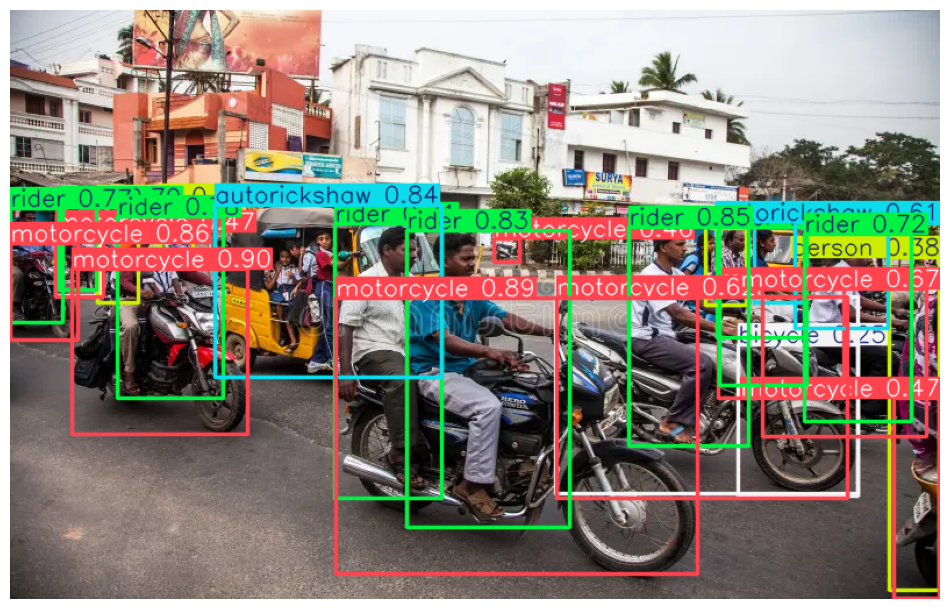

In [41]:
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx")

image_path = "/kaggle/input/datasets/mehrajalomtapadar/sqfsdff/aaaaa.webp"

results = model.predict(
    source=image_path,
    conf=0.25,
    save=False
)

import cv2
import matplotlib.pyplot as plt
result_img = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(result_img_rgb)
plt.axis("off")
plt.show()

In [43]:
# Counting onbj
from collections import Counter

image_path = "/kaggle/input/datasets/mehrajalomtapadar/sqfsdff/aaaaa.webp"
pt_model = YOLO("/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.pt")
onnx_model = YOLO("/kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx")

pt_results = pt_model.predict(image_path, conf=0.25, verbose=False)
onnx_results = onnx_model.predict(image_path, conf=0.25, verbose=False)

names = pt_model.names

def analyze_results(results, model_name):
    boxes = results[0].boxes

    class_ids = boxes.cls.cpu().numpy().astype(int)

    counts = Counter(class_ids)

    print(f"\n===== {model_name} =====")
    print(f"Total Detections: {len(class_ids)}\n")

    for cls_id, count in counts.items():
        print(f"{names[cls_id]} : {count}")

# ANALYZE
analyze_results(pt_results, "PYTORCH MODEL (.pt)")
analyze_results(onnx_results, "ONNX MODEL (.onnx)")

Loading /kaggle/working/runs/detect/vehicle_detection/yolov8n_run/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider

===== PYTORCH MODEL (.pt) =====
Total Detections: 28

motorcycle : 9
rider : 9
autorickshaw : 3
person : 4
bicycle : 3

===== ONNX MODEL (.onnx) =====
Total Detections: 28

motorcycle : 9
rider : 9
autorickshaw : 3
person : 4
bicycle : 3
